# Exploratory Data Analysis: Kikoff MMM

**Session:** Supervisor alignment meeting  
**Date:** 2026-04-13  
**Objective:** Present data exploration findings and identify critical decisions for Phase 2 modeling

## Meeting Agenda
1. Key insights from data exploration
2. Spend patterns and channel composition
3. Conversion and LTV analysis
4. Spend-conversion relationship and adstock implications
5. Seasonality patterns
6. Incrementality test insights
7. Channel mapping requirements
8. Critical decisions needed for Phase 2

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded.")

Libraries loaded.


In [10]:
# Load and prepare data
spend_df = pd.read_csv('../data/MMM_PLATFORM_CHANNEL_DAILY_SPEND_2026-04-07-1111.csv')
ltv_df = pd.read_csv('../data/MMM_DAILY_CONVENSIONS_LTV_2026-04-07-1304.csv')

# Convert dates
spend_df['DS'] = pd.to_datetime(spend_df['DS'])
ltv_df['DS'] = pd.to_datetime(ltv_df['DS'])

# Filter LTV to 2024+ (drop 2023)
ltv_df = ltv_df[ltv_df['DS'] >= '2024-01-01'].copy()

# Create combined daily dataset
daily_df = spend_df.groupby('DS')['TOTAL_SPEND'].sum().reset_index()
daily_df = daily_df.merge(ltv_df, on='DS', how='inner')

print(f"Spend data: {spend_df.shape}")
print(f"LTV data (2024+): {ltv_df.shape}")
print(f"Combined daily: {daily_df.shape}")
print(f"\nDate ranges:")
print(f"  Spend: {spend_df['DS'].min()} to {spend_df['DS'].max()}")


Spend data: (11506, 4)
LTV data (2024+): (828, 4)
Combined daily: (828, 5)

Date ranges:
  Spend: 2024-01-01 00:00:00 to 2026-04-07 00:00:00


---

# Section 1: Key Insights

The following insights are computed directly from the data and provide the foundation for our Phase 2 recommendations.

In [11]:
# Compute key metrics
spend_by_channel = spend_df.groupby('SOURCE_GROUP')['TOTAL_SPEND'].sum().sort_values(ascending=False)
top3_pct = (spend_by_channel.head(3).sum() / spend_by_channel.sum() * 100)

conv_mean = ltv_df['CONVERSIONS'].mean()
conv_peak = ltv_df['CONVERSIONS'].max()
conv_peak_date = ltv_df.loc[ltv_df['CONVERSIONS'].idxmax(), 'DS']

# Lag analysis
lag_corrs = []
for lag in range(1, 15):
    if lag < len(daily_df):
        r = daily_df['TOTAL_SPEND'].iloc[:-lag].reset_index(drop=True).corr(
            daily_df['CONVERSIONS'].iloc[lag:].reset_index(drop=True)
        )
        lag_corrs.append((lag, r))
best_lag, best_r = max(lag_corrs, key=lambda x: x[1])

# Revenue signal
daily_df['REVENUE'] = daily_df['CONVERSIONS'] * daily_df['LTV_1YEAR']
r_revenue = daily_df['TOTAL_SPEND'].corr(daily_df['REVENUE'].shift(7))
r_conversions = daily_df['TOTAL_SPEND'].corr(daily_df['CONVERSIONS'].shift(7))

# Print insights
print("KEY INSIGHTS FROM DATA EXPLORATION\n")
print(f"1. SPEND CONCENTRATION")
print(f"   Top 3 channels account for {top3_pct:.1f}% of total spend")
print(f"   Leading channels: {spend_by_channel.index[0]}, {spend_by_channel.index[1]}, {spend_by_channel.index[2]}\n")

print(f"2. CONVERSION SEASONALITY (TAX SEASON SIGNAL)")
print(f"   Conversions peaked at {conv_peak:,.0f} on {conv_peak_date.strftime('%Y-%m-%d')}")
print(f"   Baseline average: {conv_mean:,.0f} conversions/day")
print(f"   Peak-to-baseline ratio: {conv_peak/conv_mean:.2f}x\n")

print(f"3. SPEND-CONVERSION LAG (ADSTOCK SIGNAL)")
print(f"   Optimal lag: {best_lag} days")
print(f"   Peak correlation: r = {best_r:.3f}")
print(f"   Implication: Advertising effects carry over; adstock transformation required\n")

print(f"4. BAYESIAN PRIORS AVAILABLE")
print(f"   3 channels have incrementality test results")
print(f"   12+ SOURCE_GROUP values rely on data-driven estimates\n")

print(f"5. REVENUE SIGNAL STRONGER THAN CONVERSIONS")
print(f"   Revenue 7-day lagged correlation: r = {r_revenue:.3f}")
print(f"   Conversions 7-day lagged correlation: r = {r_conversions:.3f}")

KEY INSIGHTS FROM DATA EXPLORATION

1. SPEND CONCENTRATION
   Top 3 channels account for 66.8% of total spend
   Leading channels: facebook, tiktok, google

2. CONVERSION SEASONALITY (TAX SEASON SIGNAL)
   Conversions peaked at 2,775 on 2025-06-06
   Baseline average: 1,645 conversions/day
   Peak-to-baseline ratio: 1.69x

3. SPEND-CONVERSION LAG (ADSTOCK SIGNAL)
   Optimal lag: 1 days
   Peak correlation: r = 0.396
   Implication: Advertising effects carry over; adstock transformation required

4. BAYESIAN PRIORS AVAILABLE
   3 channels have incrementality test results
   12+ SOURCE_GROUP values rely on data-driven estimates

5. REVENUE SIGNAL STRONGER THAN CONVERSIONS
   Revenue 7-day lagged correlation: r = 0.458
   Conversions 7-day lagged correlation: r = 0.398


---

# Section 2: Spend Patterns

Where is the budget allocated? How stable is the channel mix over time? Are there seasonal campaign flights?

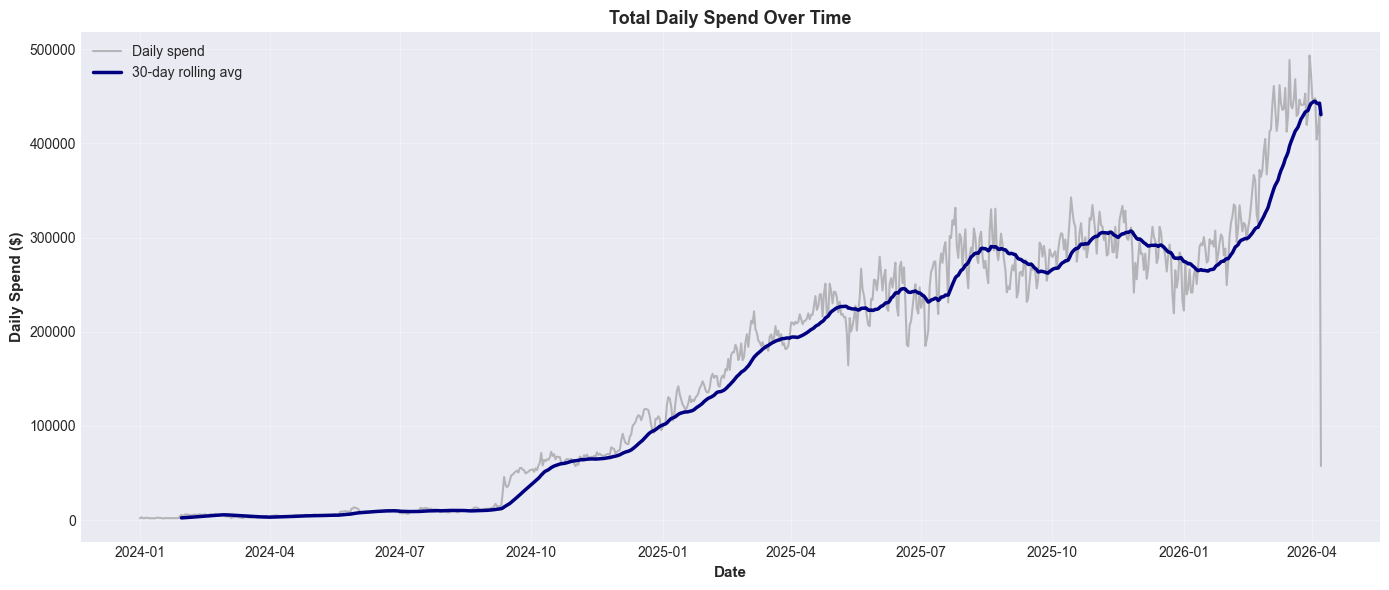

Spend summary:
  Total: $131,119,047
  Daily average: $158,356


In [12]:
# Total daily spend over time
fig, ax = plt.subplots(figsize=(14, 6))

daily_spend = spend_df.groupby('DS')['TOTAL_SPEND'].sum()
ax.plot(daily_spend.index, daily_spend.values, alpha=0.5, label='Daily spend', color='gray')
ax.plot(daily_spend.index, daily_spend.rolling(30).mean(), linewidth=2.5, label='30-day rolling avg', color='navy')

ax.set_ylabel('Daily Spend ($)', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_title('Total Daily Spend Over Time', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Spend summary:")
print(f"  Total: ${daily_spend.sum():,.0f}")
print(f"  Daily average: ${daily_spend.mean():,.0f}")

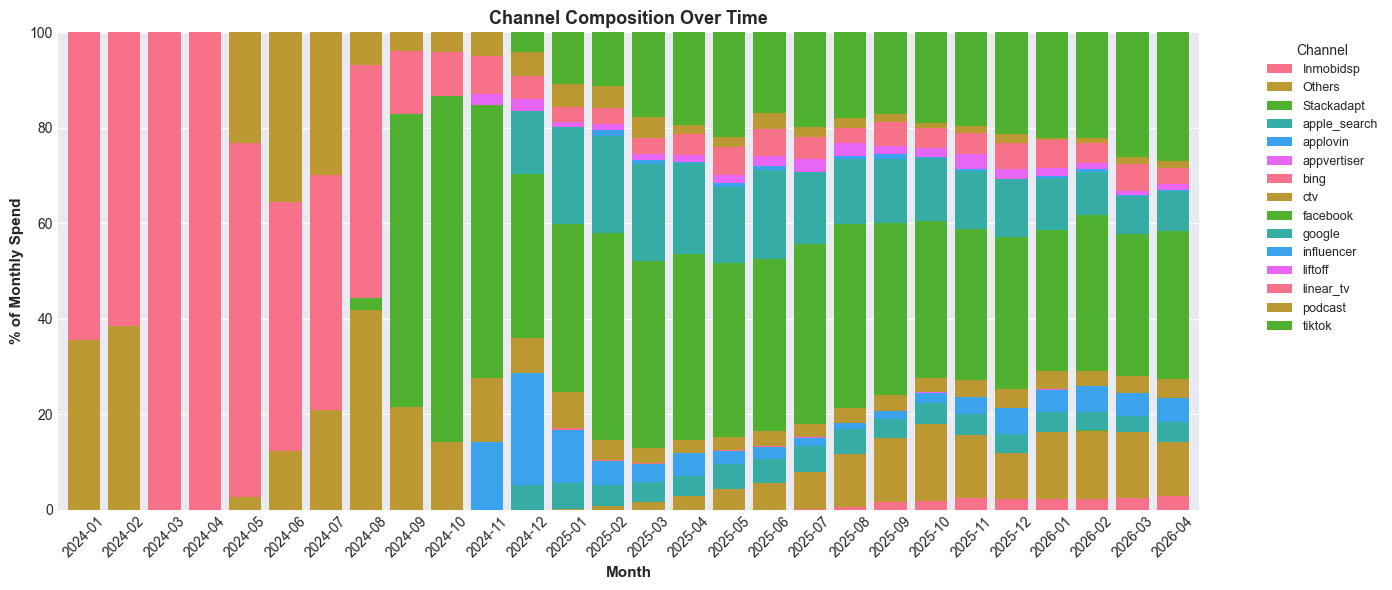

In [13]:
# Channel composition by month
spend_monthly = spend_df.groupby([pd.Grouper(key='DS', freq='ME'), 'SOURCE_GROUP'])['TOTAL_SPEND'].sum().unstack(fill_value=0)
spend_monthly_pct = spend_monthly.div(spend_monthly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
spend_monthly_pct.plot(kind='bar', stacked=True, ax=ax, width=0.8)
ax.set_ylabel('% of Monthly Spend', fontsize=11, fontweight='bold')
ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_title('Channel Composition Over Time', fontsize=13, fontweight='bold')
ax.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([d.strftime('%Y-%m') for d in spend_monthly_pct.index], rotation=45)
plt.tight_layout()
plt.show()


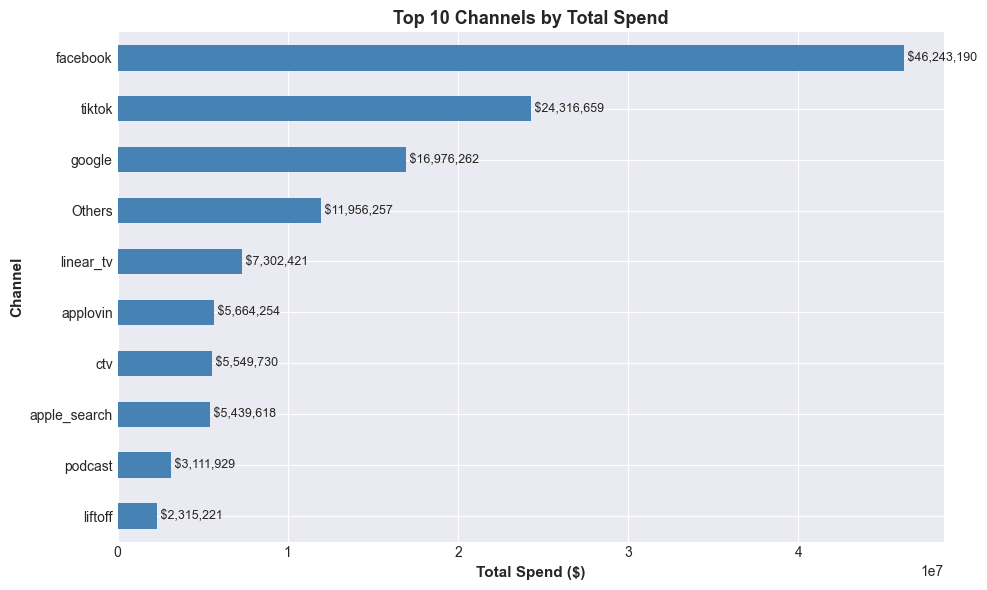

In [14]:
# Top channels
top_channels = spend_df.groupby('SOURCE_GROUP')['TOTAL_SPEND'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_channels.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total Spend ($)', fontsize=11, fontweight='bold')
ax.set_ylabel('Channel', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Channels by Total Spend', fontsize=13, fontweight='bold')
for i, v in enumerate(top_channels.values):
    ax.text(v, i, f' ${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Required Clarification: Platform Data Structure

The PLATFORM column contains 2,518 rows labeled "web and app" and 35 rows labeled "iOS and android" in addition to clean ios/android/web splits.

**For discussion:** Are these combined platform values intentional segments in your reporting structure, or artifacts from data pipeline aggregation? This determines whether we model at channel level only or also differentiate by platform.

---

# Section 3: Conversion and LTV Analysis

What does the target variable look like? Is revenue a better optimization target than volume alone?

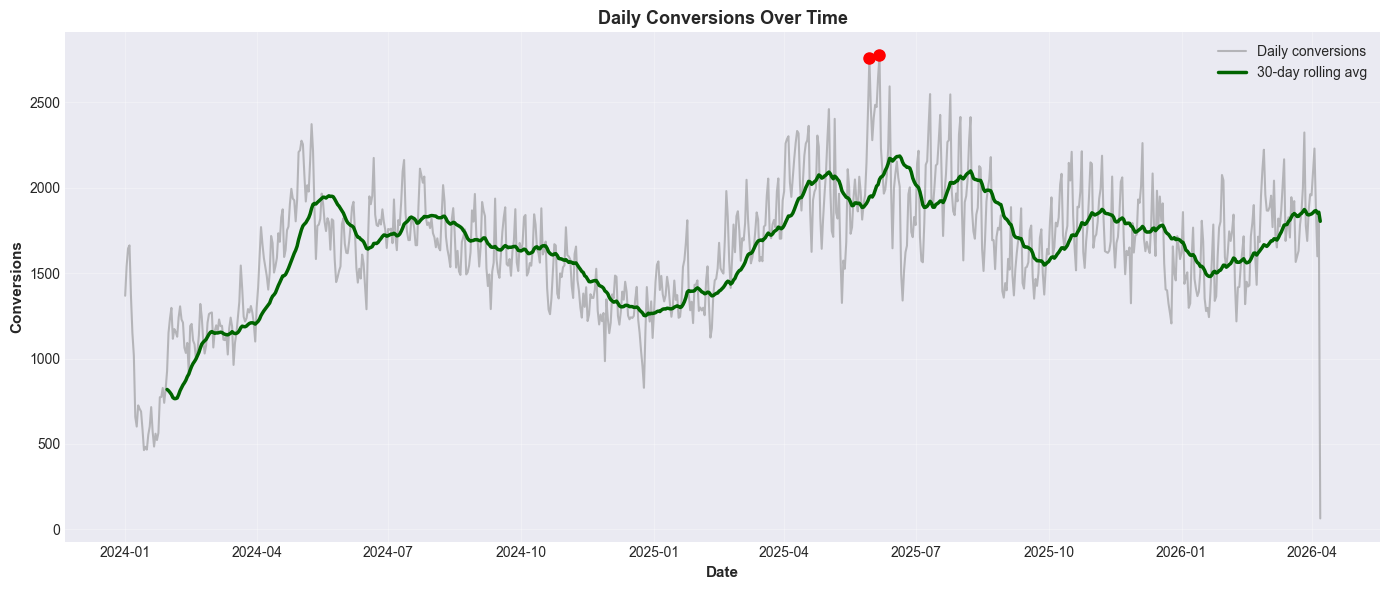

Conversions summary:
  Mean: 1,645
  Range: 64 to 2,775


In [15]:
# Daily conversions
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ltv_df['DS'], ltv_df['CONVERSIONS'], alpha=0.5, label='Daily conversions', color='gray')
ax.plot(ltv_df['DS'], ltv_df['CONVERSIONS'].rolling(30).mean(), linewidth=2.5, label='30-day rolling avg', color='darkgreen')

# Outliers
outlier_threshold = ltv_df['CONVERSIONS'].mean() + 3 * ltv_df['CONVERSIONS'].std()
outliers = ltv_df[ltv_df['CONVERSIONS'] > outlier_threshold]
for idx, row in outliers.iterrows():
    ax.plot(row['DS'], row['CONVERSIONS'], 'ro', markersize=8)

ax.set_ylabel('Conversions', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_title('Daily Conversions Over Time', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Conversions summary:")
print(f"  Mean: {ltv_df['CONVERSIONS'].mean():,.0f}")
print(f"  Range: {ltv_df['CONVERSIONS'].min():,.0f} to {ltv_df['CONVERSIONS'].max():,.0f}")

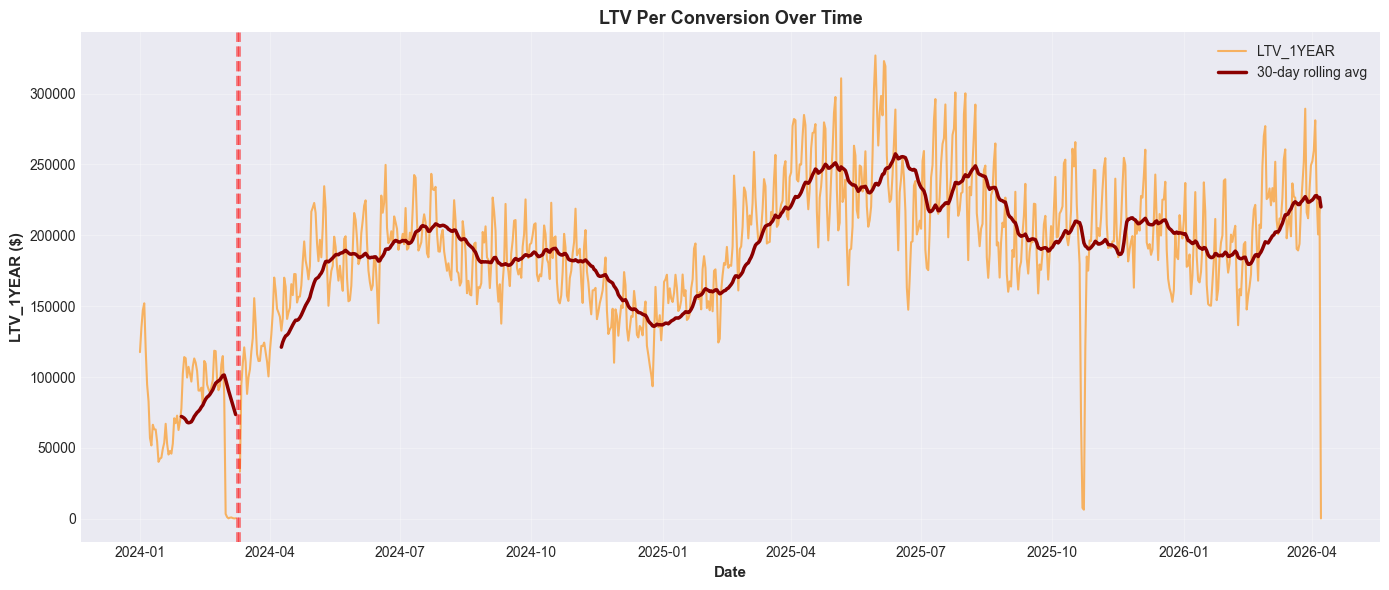

LTV_1YEAR summary:
  Mean: $185,515.37
  Null rows: 2 (['2024-03-09', '2024-03-10'])


In [16]:
# LTV over time
fig, ax = plt.subplots(figsize=(14, 6))

null_ltv = ltv_df[ltv_df['LTV_1YEAR'].isna()]

ax.plot(ltv_df['DS'], ltv_df['LTV_1YEAR'], alpha=0.6, label='LTV_1YEAR', color='darkorange')
ax.plot(ltv_df['DS'], ltv_df['LTV_1YEAR'].rolling(30).mean(), linewidth=2.5, label='30-day rolling avg', color='darkred')

# Null dates
for idx, row in null_ltv.iterrows():
    ax.axvline(row['DS'], color='red', linestyle='--', alpha=0.5, linewidth=2)

ax.set_ylabel('LTV_1YEAR ($)', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_title('LTV Per Conversion Over Time', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"LTV_1YEAR summary:")
print(f"  Mean: ${ltv_df['LTV_1YEAR'].mean():,.2f}")
print(f"  Null rows: {ltv_df['LTV_1YEAR'].isna().sum()} ({null_ltv['DS'].dt.strftime('%Y-%m-%d').tolist()})")

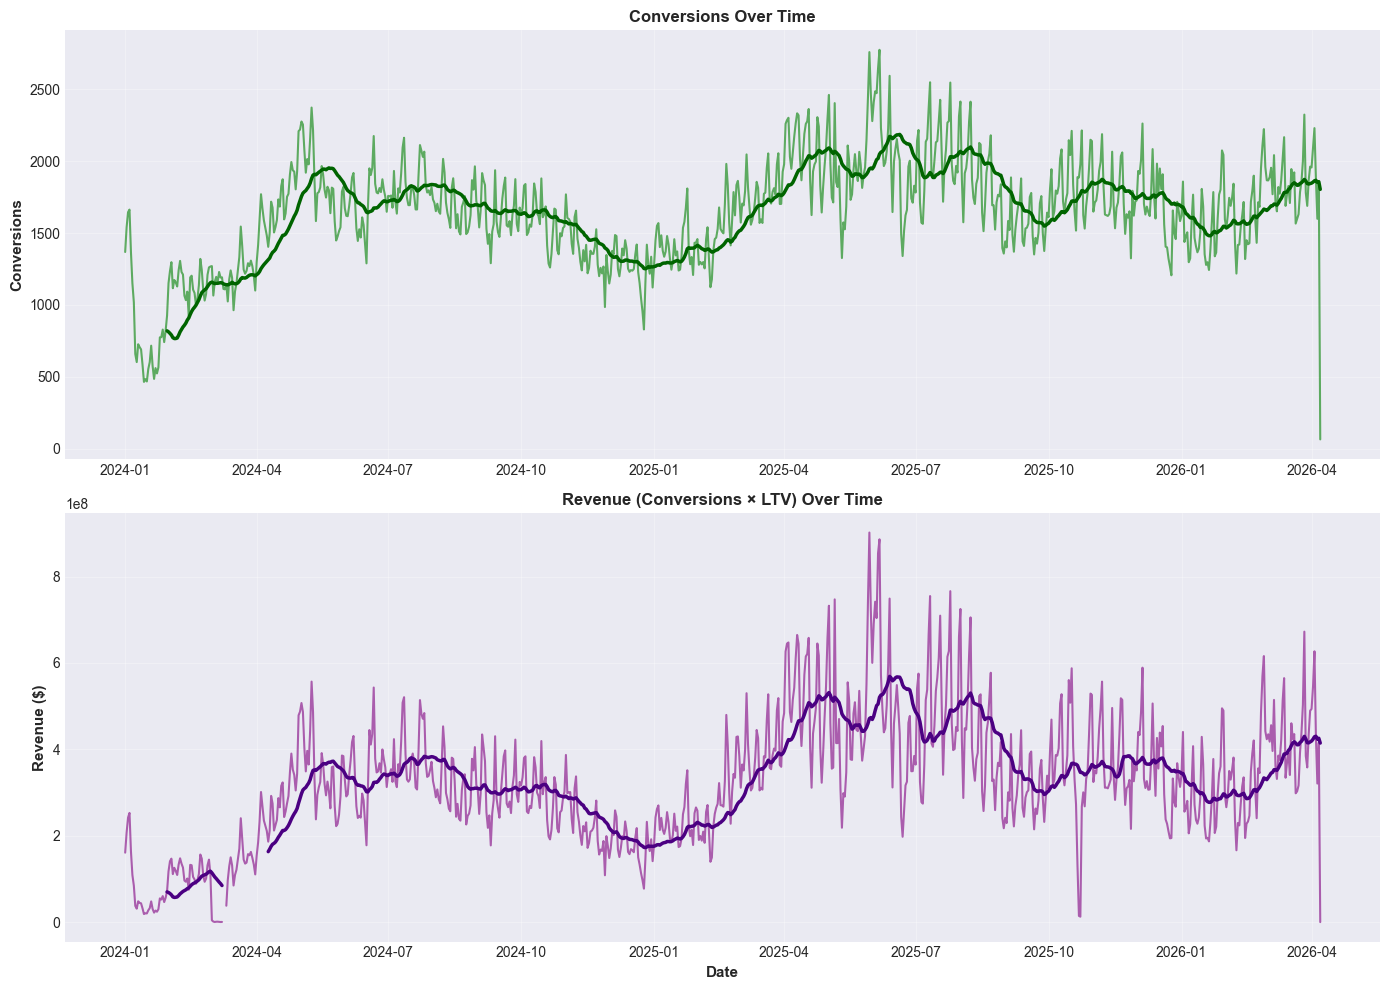

In [17]:
# Revenue proxy
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(daily_df['DS'], daily_df['CONVERSIONS'], alpha=0.6, color='green', label='Conversions')
ax1.plot(daily_df['DS'], daily_df['CONVERSIONS'].rolling(30).mean(), linewidth=2.5, color='darkgreen')
ax1.set_ylabel('Conversions', fontsize=11, fontweight='bold')
ax1.set_title('Conversions Over Time', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(daily_df['DS'], daily_df['REVENUE'], alpha=0.6, color='purple', label='Revenue')
ax2.plot(daily_df['DS'], daily_df['REVENUE'].rolling(30).mean(), linewidth=2.5, color='indigo')
ax2.set_ylabel('Revenue ($)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_title('Revenue (Conversions × LTV) Over Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Required Decision: Target Variable Selection

The data contains two candidate target metrics:
- **CONVERSIONS**: Purchase volume (purchases per day)
- **LTV_1YEAR**: Per-conversion customer lifetime value

Preliminary analysis suggests that revenue (conversions × LTV) may provide a more stable signal than conversions alone, with stronger correlation to spend patterns.

**For discussion:** Should the MMM model target (1) purchase volume, (2) per-conversion value, or (3) total revenue? If modeling revenue, should we use 1-year or 3-year LTV horizon?

## Required Clarification: LTV Data Quality

Data validation identified 2 null LTV values (2024-03-09 and 2024-03-10). During our initial conversation, you mentioned approximately 10 bad LTV values requiring smoothing before modeling.

**For discussion:** Can you identify which of the remaining ~8 dates have problematic LTV values? Please provide either a list of specific dates, or a threshold/rule (e.g., LTV outside of a defined range, or exceeding N standard deviations from the rolling mean).

---

# Section 4: Spend-Conversion Relationship

The foundation of MMM. Does spend drive conversions? What is the typical lag?

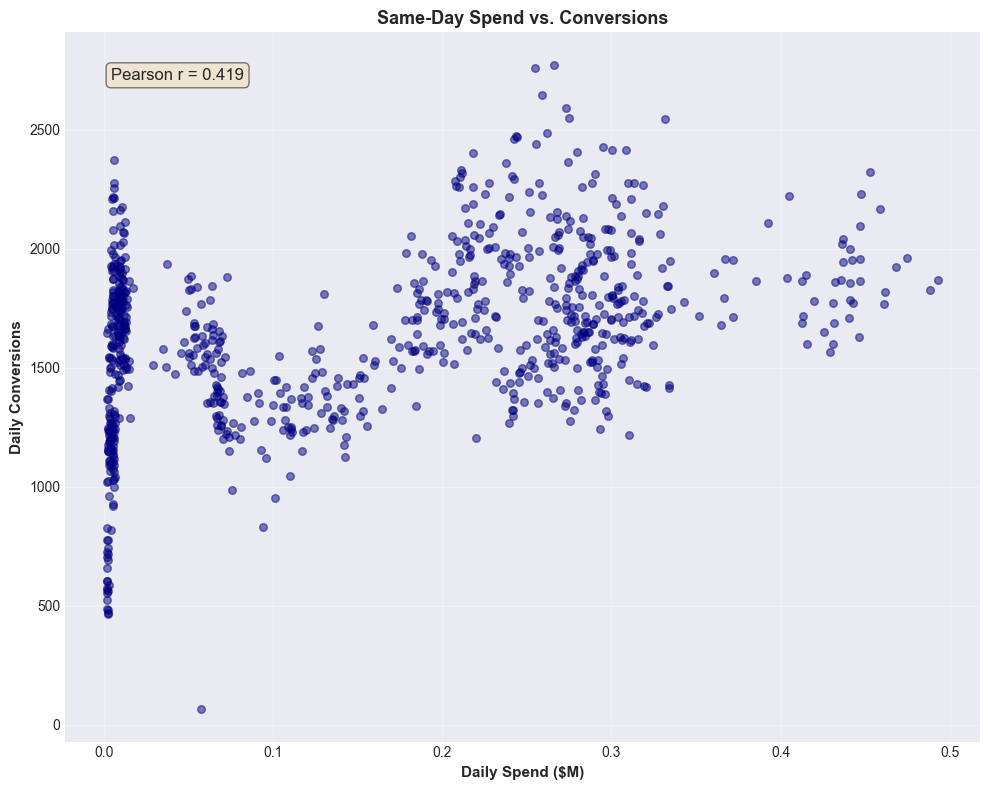

Same-day correlation: r = 0.4186
Weak correlation indicates advertising effects carry over.


In [18]:
# Same-day correlation
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(daily_df['TOTAL_SPEND'] / 1e6, daily_df['CONVERSIONS'], alpha=0.5, s=30, color='navy')

r = daily_df['TOTAL_SPEND'].corr(daily_df['CONVERSIONS'])
ax.text(0.05, 0.95, f'Pearson r = {r:.3f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Daily Spend ($M)', fontsize=11, fontweight='bold')
ax.set_ylabel('Daily Conversions', fontsize=11, fontweight='bold')
ax.set_title('Same-Day Spend vs. Conversions', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Same-day correlation: r = {r:.4f}")
print(f"Weak correlation indicates advertising effects carry over.")

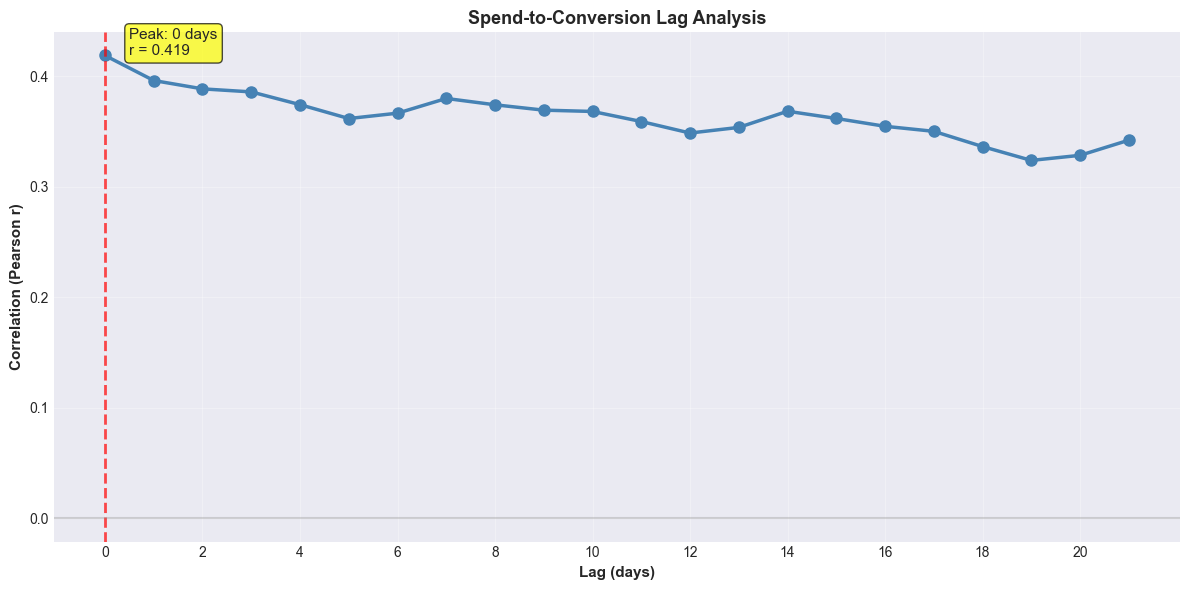

Peak correlation at 0-day lag: r = 0.4186


In [19]:
# Lagged correlation
lag_results = []
for lag in range(0, 22):
    if lag < len(daily_df):
        r = daily_df['TOTAL_SPEND'].iloc[:-lag if lag > 0 else None].reset_index(drop=True).corr(
            daily_df['CONVERSIONS'].iloc[lag:].reset_index(drop=True)
        )
        lag_results.append({'lag': lag, 'correlation': r})

lag_df = pd.DataFrame(lag_results)
best_lag = lag_df.loc[lag_df['correlation'].idxmax()]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lag_df['lag'], lag_df['correlation'], marker='o', linewidth=2.5, markersize=8, color='steelblue')
ax.axvline(best_lag['lag'], color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)

ax.text(best_lag['lag'] + 0.5, best_lag['correlation'],
        f"Peak: {best_lag['lag']:.0f} days\nr = {best_lag['correlation']:.3f}",
        fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Lag (days)', fontsize=11, fontweight='bold')
ax.set_ylabel('Correlation (Pearson r)', fontsize=11, fontweight='bold')
ax.set_title('Spend-to-Conversion Lag Analysis', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 22, 2))
plt.tight_layout()
plt.show()

print(f"Peak correlation at {best_lag['lag']:.0f}-day lag: r = {best_lag['correlation']:.4f}")

## Adstock and Carryover Effects

Marketing Mix Modeling accounts for the reality that advertising effects are not immediate. Spend on a given day typically influences conversions over subsequent days rather than only on the day of spend.

**Adstock transformation** models this carryover by assuming spend effects decay exponentially over time:
- Day T: 100% of effect materializes
- Day T+1: A percentage of the original effect
- Day T+2: An even smaller percentage, continuing to decay

The model will estimate this decay rate and the half-life. Incrementality test results help calibrate these estimates.

*(Note: specific adstock parameters shown here are illustrative — final estimates from Phase 2 model fitting.)*

---

# Section 5: Seasonality

Calendar-based patterns in spend and conversions.

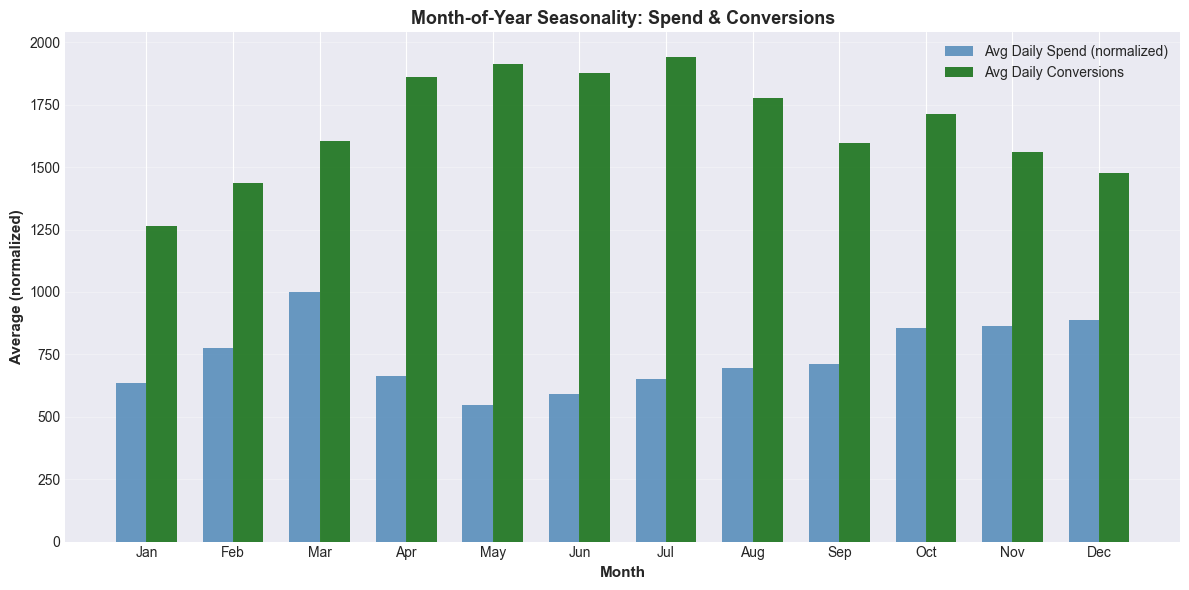

Tax season (Jan-Apr) avg conversions: 1519
Rest of year avg conversions: 1733
Ratio: 0.88x


In [20]:
# Month-of-year
daily_df['MONTH'] = daily_df['DS'].dt.month
daily_df['MONTH_NAME'] = daily_df['DS'].dt.strftime('%B')

monthly_stats = daily_df.groupby(['MONTH', 'MONTH_NAME']).agg({
    'TOTAL_SPEND': 'mean',
    'CONVERSIONS': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(monthly_stats))
width = 0.35

spend_norm = monthly_stats['TOTAL_SPEND'] / monthly_stats['TOTAL_SPEND'].max() * 1000
conv_norm = monthly_stats['CONVERSIONS']

ax.bar(x - width/2, spend_norm, width, label='Avg Daily Spend (normalized)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, conv_norm, width, label='Avg Daily Conversions', color='darkgreen', alpha=0.8)

ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Average (normalized)', fontsize=11, fontweight='bold')
ax.set_title('Month-of-Year Seasonality: Spend & Conversions', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m[:3] for m in monthly_stats['MONTH_NAME']])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

tax_season_conv = daily_df[daily_df['MONTH'].isin([1, 2, 3, 4])]['CONVERSIONS'].mean()
rest_conv = daily_df[~daily_df['MONTH'].isin([1, 2, 3, 4])]['CONVERSIONS'].mean()
print(f"Tax season (Jan-Apr) avg conversions: {tax_season_conv:.0f}")
print(f"Rest of year avg conversions: {rest_conv:.0f}")
print(f"Ratio: {tax_season_conv / rest_conv:.2f}x")

---

# Section 6: Incrementality Test Insights

Empirical evidence of channel effectiveness from controlled experiments.

In [21]:
# Incrementality summary
incrementality_summary = pd.DataFrame([
    {'Channel': 'TikTok', 'Period': 'Aug 22 - Sep 15, 2025', 'Type': 'Holdout', 'Status': 'Clean'},
    {'Channel': 'Meta', 'Period': 'May 6 - May 14, 2025', 'Type': 'Holdout (ended early)', 'Status': 'Usable'},
    {'Channel': 'Meta', 'Period': 'Jan 3 - Jan 8, 2026', 'Type': 'Holdout (cancelled)', 'Status': 'Uncertain'},
    {'Channel': 'CTV', 'Period': 'Oct 6 - Nov 2, 2025', 'Type': 'Geo holdout', 'Status': 'Clean'}
])

print("INCREMENTALITY TEST RESULTS")
print(incrementality_summary.to_string(index=False))

# iCAC table
icroas_data = [
    {'Channel': 'TikTok', 'Platform': 'iOS', 'iCAC': 108.83},
    {'Channel': 'TikTok', 'Platform': 'Android', 'iCAC': 81.68},
    {'Channel': 'TikTok', 'Platform': 'Web', 'iCAC': 112.12},
    {'Channel': 'Meta (May)', 'Platform': 'iOS', 'iCAC': 135.48},
    {'Channel': 'Meta (May)', 'Platform': 'Android', 'iCAC': 63.06},
    {'Channel': 'Meta (May)', 'Platform': 'Web', 'iCAC': 156.89},
    {'Channel': 'CTV', 'Platform': 'All', 'iCAC': 135.00}
]
icroas_df = pd.DataFrame(icroas_data)

print("\niCAC BY PLATFORM (excludes cancelled Jan 2026 Meta test)")
print(icroas_df.to_string(index=False))

INCREMENTALITY TEST RESULTS
Channel                Period                  Type    Status
 TikTok Aug 22 - Sep 15, 2025               Holdout     Clean
   Meta  May 6 - May 14, 2025 Holdout (ended early)    Usable
   Meta   Jan 3 - Jan 8, 2026   Holdout (cancelled) Uncertain
    CTV   Oct 6 - Nov 2, 2025           Geo holdout     Clean

iCAC BY PLATFORM (excludes cancelled Jan 2026 Meta test)
   Channel Platform   iCAC
    TikTok      iOS 108.83
    TikTok  Android  81.68
    TikTok      Web 112.12
Meta (May)      iOS 135.48
Meta (May)  Android  63.06
Meta (May)      Web 156.89
       CTV      All 135.00


## Test Data Quality: January 2026 Meta Study

The January 2026 Meta test was cancelled, and spend figures are approximate due to data export limitations. While incremental CAC estimates are available, the reliability of these values is uncertain given the test circumstances.

**For discussion:** How should we handle this test in Bayesian calibration? Options include treating it as a prior with wider uncertainty bounds, or excluding it from calibration and relying only on the completed May 2025 Meta test.

---

# Section 7: Channel Taxonomy Mapping

The critical alignment requirement for Phase 2.

In [22]:
# Channel mapping template
source_group_values = sorted(spend_df['SOURCE_GROUP'].unique())

mapping_template = pd.DataFrame({
    'SOURCE_GROUP': source_group_values,
    'Best_Guess': [
        'Meta', 'Google/Search', 'TikTok', 'Mobile DSP', 'Others',
        'Mobile DSP', 'Linear TV', 'CTV', 'Audio/Podcast', 'Apple Search',
        'Mobile DSP?', 'DSP?', 'Influencers', 'Bing Search?', 'DSP?'
    ],
    'Confidence': [
        'High', 'Low', 'High', 'Low', 'Medium', 'Low', 'High', 'High',
        'Low', 'High', 'Low', 'Low', 'Medium', 'Low', 'Low'
    ]
})

print("CHANNEL MAPPING: YOUR INPUT REQUIRED\n")
print(mapping_template.to_string(index=False))
print("\nPlease map each SOURCE_GROUP to your business channel taxonomy.")

CHANNEL MAPPING: YOUR INPUT REQUIRED

SOURCE_GROUP    Best_Guess Confidence
   Inmobidsp          Meta       High
      Others Google/Search        Low
  Stackadapt        TikTok       High
apple_search    Mobile DSP        Low
    applovin        Others     Medium
 appvertiser    Mobile DSP        Low
        bing     Linear TV       High
         ctv           CTV       High
    facebook Audio/Podcast        Low
      google  Apple Search       High
  influencer   Mobile DSP?        Low
     liftoff          DSP?        Low
   linear_tv   Influencers     Medium
     podcast  Bing Search?        Low
      tiktok          DSP?        Low

Please map each SOURCE_GROUP to your business channel taxonomy.


## Critical Input Required: Channel Taxonomy Mapping

**This is the primary blocking item for Phase 2 execution.**

The spend data contains 15 SOURCE_GROUP values from your data system, but our understanding is that your business operates across 12-13 marketing channels. While some SOURCE_GROUP values map clearly to business channels (facebook → Meta, tiktok → TikTok), others require clarification. Specifically, we need to understand whether values like applovin, liftoff, and appvertiser represent distinct channels or are sub-tactics within a broader channel grouping (for example, multiple demand-side platform vendors).

**Required:** Please map each SOURCE_GROUP value to the corresponding channel in your business model and clarify whether programmatic/DSP vendors should be grouped as a single channel or kept separate.

---

# Section 8: Critical Decisions for Phase 2

The following decisions are required before Phase 2 development can proceed.

In [23]:
decisions_summary = """
CRITICAL DECISIONS FOR PHASE 2
======================================================================

BLOCKING (required before proceeding):

  1. Channel Taxonomy Mapping
     Question: How do 15 SOURCE_GROUP values map to 12-13 business channels?
     Impact: Determines model parameter space and all downstream reporting

  2. Platform Data Handling
     Question: Model at channel level only, or differentiate by platform?
     Impact: Affects model granularity and parameter space dimensionality

  3. Primary Optimization Target
     Question: CONVERSIONS, LTV_1YEAR, or REVENUE composite?
     Impact: Shapes model objective function and all ROI estimates

IMPORTANT (shapes calibration):

  4. Test Data Quality
     Question: Include Jan 2026 Meta test with wider uncertainty, or exclude?
     Impact: Affects prior specification for Meta channel

  5. LTV Anomalies
     Question: Which ~8 dates are bad beyond the 2 identified nulls?
     Impact: Data preprocessing and time-series stability

======================================================================
"""

print(decisions_summary)


CRITICAL DECISIONS FOR PHASE 2

BLOCKING (required before proceeding):

  1. Channel Taxonomy Mapping
     Question: How do 15 SOURCE_GROUP values map to 12-13 business channels?
     Impact: Determines model parameter space and all downstream reporting

  2. Platform Data Handling
     Question: Model at channel level only, or differentiate by platform?
     Impact: Affects model granularity and parameter space dimensionality

  3. Primary Optimization Target
     Question: CONVERSIONS, LTV_1YEAR, or REVENUE composite?
     Impact: Shapes model objective function and all ROI estimates

IMPORTANT (shapes calibration):

  4. Test Data Quality
     Question: Include Jan 2026 Meta test with wider uncertainty, or exclude?
     Impact: Affects prior specification for Meta channel

  5. LTV Anomalies
     Question: Which ~8 dates are bad beyond the 2 identified nulls?
     Impact: Data preprocessing and time-series stability




In [24]:
readiness_summary = """
READINESS ASSESSMENT
======================================================================

COMPLETED:
  Data alignment: 828 days validated (2024-01-01 to 2026-04-07)
  Spend patterns: 15 SOURCE_GROUP channels identified
  Conversion signal: Peak in May-June 2025, consistent with tax season
  Carryover effects: Spend-conversion lag identified
  Seasonality: Jan-Apr shows elevated conversion rates
  Incrementality tests: 4 studies identified; 3 ready for calibration
  Target variable: Revenue signal stronger than volume alone

AWAITING DECISIONS:
  Channel mapping (15 → 12-13)
  Platform aggregation approach
  Primary optimization target

NEXT PHASE (ready to execute post-decision):
  Data preprocessing
  Feature engineering
  Bayesian calibration
  Model development

======================================================================
"""

print(readiness_summary)


READINESS ASSESSMENT

COMPLETED:
  Data alignment: 828 days validated (2024-01-01 to 2026-04-07)
  Spend patterns: 15 SOURCE_GROUP channels identified
  Conversion signal: Peak in May-June 2025, consistent with tax season
  Carryover effects: Spend-conversion lag identified
  Seasonality: Jan-Apr shows elevated conversion rates
  Incrementality tests: 4 studies identified; 3 ready for calibration
  Target variable: Revenue signal stronger than volume alone

AWAITING DECISIONS:
  Channel mapping (15 → 12-13)
  Platform aggregation approach
  Primary optimization target

NEXT PHASE (ready to execute post-decision):
  Data preprocessing
  Feature engineering
  Bayesian calibration
  Model development




---

# Next Steps

To proceed with Phase 2 development, alignment is needed on three critical decisions:

1. **Channel taxonomy mapping:** Clarify which SOURCE_GROUP values map to which business channels
2. **Platform data structure:** Confirm whether to model at channel level only or differentiate by platform
3. **Optimization target:** Confirm whether to model purchase volume, customer lifetime value, or total revenue

Once these items are resolved, Phase 2 development can proceed immediately with data preprocessing, feature engineering, and model development.

---

*Exploratory data analysis completed 2026-04-13 | Kikoff Marketing Mix Modeling Team*